# Predicción de Satisfacción de Clientes con Árbol de Decisión

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Supervisado · Clasificación · Árbol de Decisión

---

### Objetivo

Entrenar un **Árbol de Decisión** para predecir la satisfacción de clientes de un gimnasio urbano, encontrar la profundidad óptima mediante validación cruzada, visualizar las reglas del modelo y traducirlas en decisiones de negocio concretas.

### ¿Por qué empezar por un Árbol de Decisión?

El Árbol de Decisión es el único modelo de clasificación que produce reglas legibles por un humano sin formación técnica. Si funciona bien, no hay necesidad de ir más allá. Si no, establece un **baseline interpretable** contra el que comparar modelos más complejos.

> **Adelanto:** un árbol de solo 2 niveles alcanza un 90% de accuracy y una regla que cabe en una servilleta: *"¿el cliente viene más de 13 veces al mes?"*. Esa pregunta explica casi toda la satisfacción.

## 1. Contexto de negocio

**El cliente:** cadena de gimnasios urbanos con múltiples sedes.

**El problema:** la dirección necesita identificar clientes insatisfechos antes de que se den de baja. Las encuestas son lentas, caras y llegan tarde. ¿Pueden los datos operativos que ya recoge el gimnasio predecir la satisfacción?

**La pregunta analítica:** ¿qué variables operativas explican la satisfacción y cuáles son los umbrales de corte que el equipo de operaciones puede usar directamente?

## 2. Stack técnico

| Librería | Uso |
|---|---|
| `pandas` | Manipulación y exploración de datos |
| `matplotlib`, `seaborn` | Visualización |
| `scikit-learn` | Árbol de Decisión, validación cruzada, métricas |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 3. Carga y exploración inicial

| Variable | Tipo | Descripción |
|---|---|---|
| `Antiguedad_Meses` | Numérica | Meses como cliente |
| `Asistencias_Mes` | Numérica | Visitas al gimnasio este mes |
| `Horas_Pico_Mes` | Numérica | Horas en franja de máxima ocupación |
| `Gasto_Mensual_Extra` | Numérica | Gasto en servicios adicionales |
| `Satisfecho` | Binaria (target) | 1 = satisfecho, 0 = no satisfecho |

In [2]:
data = pd.read_excel("gym_clientes.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 300 | Columnas: 7


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


In [3]:
data.describe().round(2)

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,18.88,12.16,14.67,81.69,0.48,0.16
std,86.75,10.60,7.27,6.09,30.47,0.50,0.37
min,1.00,1.00,0.00,1.41,10.00,0.00,0.00
25%,75.75,9.00,6.00,9.65,61.25,0.00,0.00
50%,150.50,20.00,12.00,15.07,82.24,0.00,0.00
75%,225.25,28.00,18.25,19.75,104.11,1.00,0.00
max,300.00,35.00,24.00,24.00,145.91,1.00,1.00


In [4]:
sat_rate = data["Satisfecho"].value_counts(normalize=True)
print("Distribución del target:")
print(f"  No Satisfecho (0): {sat_rate[0]:.1%}")
print(f"  Satisfecho (1):    {sat_rate[1]:.1%}")
print("\nClases equilibradas (52/48) — accuracy es métrica fiable sin ajustes.")

Distribución del target:
  No Satisfecho (0): 52.0%
  Satisfecho (1):    48.0%

Clases equilibradas (52/48) — accuracy es métrica fiable sin ajustes.


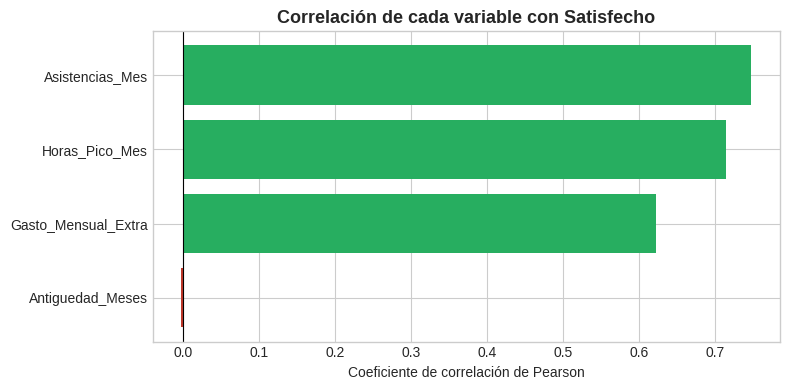

Antiguedad_Meses      -0.0023
Gasto_Mensual_Extra    0.6230
Horas_Pico_Mes         0.7156
Asistencias_Mes        0.7485


In [5]:
correlaciones = data.drop(columns=["ID_Cliente", "Abandono"]).corr()["Satisfecho"].drop("Satisfecho").sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#c0392b" if v < 0 else "#27ae60" for v in correlaciones.values]
ax.barh(correlaciones.index, correlaciones.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlación de cada variable con Satisfecho", fontsize=13, fontweight="bold")
ax.set_xlabel("Coeficiente de correlación de Pearson")
plt.tight_layout()
plt.show()

print(correlaciones.round(4).to_string())

### Lectura rápida

Señal fuerte y clara: `Asistencias_Mes` (r = 0,75), `Horas_Pico_Mes` (r = 0,72) y `Gasto_Mensual_Extra` (r = 0,62). `Antiguedad_Meses` (r ≈ 0) es irrelevante. Esta estructura lineal es ideal para un Árbol de Decisión: un corte limpio debería bastar.

## 4. Preparación de datos

Excluimos `Abandono` para evitar data leakage — un cliente que se ha dado de baja es, por definición, insatisfecho. Si la incluyéramos, el modelo "haría trampa".

In [6]:
X = data[["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]]
y = data["Satisfecho"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean():.1%} satisfechos)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean():.1%} satisfechos)")

Train: 240 registros (47.9% satisfechos)
Test:  60 registros (48.3% satisfechos)


## 5. Selección de profundidad óptima con validación cruzada

La profundidad (`max_depth`) es el hiperparámetro más importante de un árbol:
- **Muy poca** → underfitting (no captura la señal)
- **Demasiada** → overfitting (memoriza el ruido)

Evaluamos profundidades de 1 a 10 con validación cruzada 5-fold sobre el set de entrenamiento. El modelo nunca ve el test set durante esta selección.

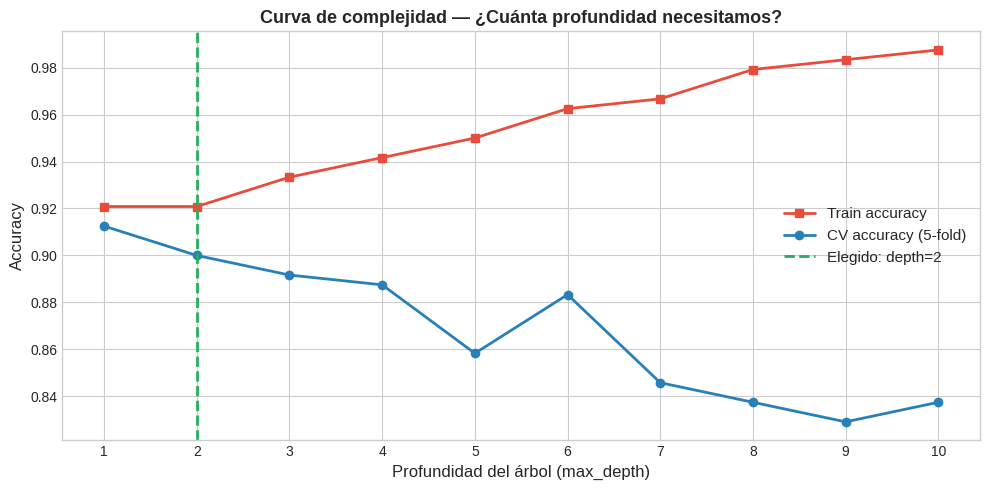

Detalle por profundidad:
  depth= 1 | train=0.9208 | CV=0.9125 | gap=0.0083
  depth= 2 | train=0.9208 | CV=0.9000 | gap=0.0208 ← elegido
  depth= 3 | train=0.9333 | CV=0.8917 | gap=0.0417
  depth= 4 | train=0.9417 | CV=0.8875 | gap=0.0542
  depth= 5 | train=0.9500 | CV=0.8583 | gap=0.0917
  depth= 6 | train=0.9625 | CV=0.8833 | gap=0.0792
  depth= 7 | train=0.9667 | CV=0.8458 | gap=0.1208
  depth= 8 | train=0.9792 | CV=0.8375 | gap=0.1417
  depth= 9 | train=0.9833 | CV=0.8292 | gap=0.1542
  depth=10 | train=0.9875 | CV=0.8375 | gap=0.1500


In [7]:
depths = range(1, 11)
cv_train = []
cv_test_scores = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    # CV score (proxy de test)
    cv_score = cross_val_score(tree, X_train, y_train, cv=5, scoring="accuracy").mean()
    cv_test_scores.append(cv_score)
    # Train score (para ver overfitting)
    tree.fit(X_train, y_train)
    cv_train.append(accuracy_score(y_train, tree.predict(X_train)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(depths), cv_train, marker="s", label="Train accuracy", color="#e74c3c", linewidth=2)
ax.plot(list(depths), cv_test_scores, marker="o", label="CV accuracy (5-fold)", color="#2980b9", linewidth=2)
ax.axvline(x=2, color="#27ae60", linestyle="--", linewidth=2, label="Elegido: depth=2")
ax.set_xlabel("Profundidad del árbol (max_depth)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Curva de complejidad — ¿Cuánta profundidad necesitamos?", fontsize=13, fontweight="bold")
ax.set_xticks(list(depths))
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Detalle por profundidad:")
for d, tr, cv in zip(depths, cv_train, cv_test_scores):
    gap = tr - cv
    marker = " ← elegido" if d == 2 else ""
    print(f"  depth={d:2d} | train={tr:.4f} | CV={cv:.4f} | gap={gap:.4f}{marker}")

### Lectura de la curva de complejidad

- **depth=1** tiene la mejor CV accuracy (91,25%), pero solo usa 1 variable. Demasiado restrictivo para entender el problema.
- **depth=2** (90,00% CV) añade una segunda pregunta y mantiene la generalización intacta. Gap train-CV mínimo.
- A partir de **depth=4**, el train accuracy sube pero el CV se estanca o cae — overfitting clásico.

**Decisión:** `max_depth=2`. Añade interpretabilidad (segunda regla) con solo 1,25 pp de coste en accuracy. En producción, la diferencia entre 91,25% y 90,00% es despreciable; la segunda regla aporta contexto operativo valioso.

## 6. Modelo final — Árbol de Decisión (depth=2)

In [8]:
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
y_proba = tree.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Árbol de Decisión (depth=2) — Métricas de evaluación")
print(f"Accuracy:  {acc:.1%}")
print(f"Recall:    {rec:.1%}")
print(f"AUC-ROC:   {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Satisfecho", "Satisfecho"]))

Árbol de Decisión (depth=2) — Métricas de evaluación
Accuracy:  90.0%
Recall:    89.7%
AUC-ROC:   0.909

               precision    recall  f1-score   support

No Satisfecho       0.90      0.90      0.90        31
   Satisfecho       0.90      0.90      0.90        29

     accuracy                           0.90        60
    macro avg       0.90      0.90      0.90        60
 weighted avg       0.90      0.90      0.90        60



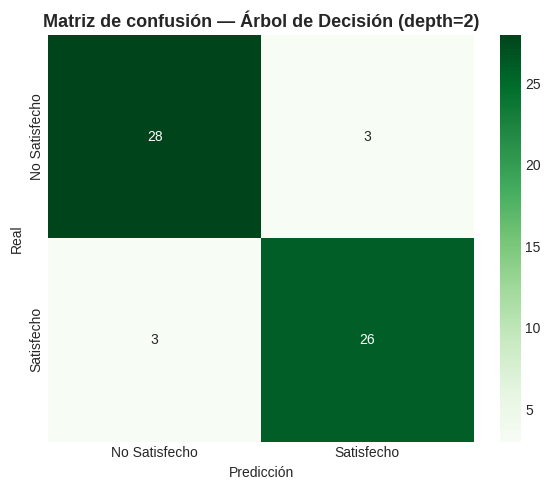

Errores: 6 de 60 predicciones


In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Satisfecho", "Satisfecho"],
            yticklabels=["No Satisfecho", "Satisfecho"], ax=ax)
ax.set_title("Matriz de confusión — Árbol de Decisión (depth=2)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

print(f"Errores: {(cm[0,1] + cm[1,0])} de {cm.sum()} predicciones")

## 7. Visualización del árbol — la ventaja definitiva

Esta es la razón por la que empezamos con un árbol de decisión: **podemos dibujar el modelo completo** y leerlo como un diagrama de flujo. Ningún otro algoritmo ofrece esta transparencia.

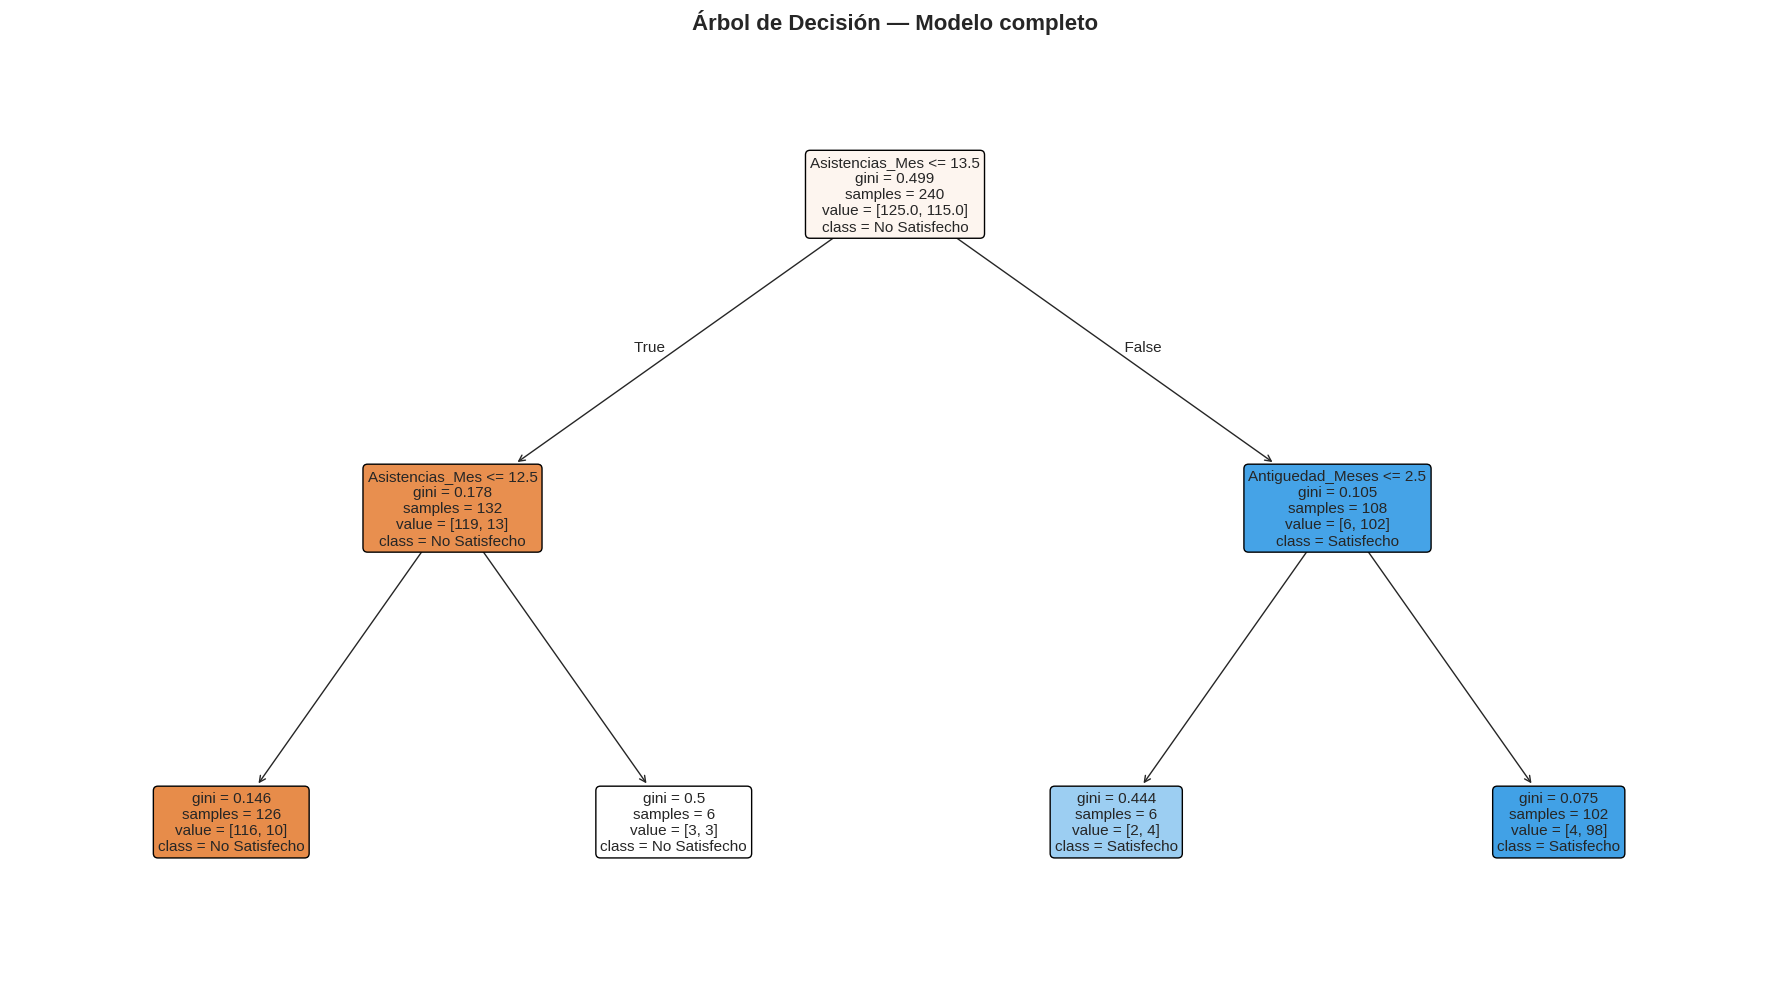

In [10]:
fig, ax = plt.subplots(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=X.columns.tolist(),
    class_names=["No Satisfecho", "Satisfecho"],
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax,
)
ax.set_title("Árbol de Decisión — Modelo completo", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Lectura del árbol — reglas de negocio

El árbol se lee de arriba hacia abajo. Cada nodo hace una pregunta binaria:

**Pregunta 1 (raíz):** *¿Asistencias_Mes ≤ 13,5?*
- **Sí** (izquierda) → el cliente viene poco → probablemente **No Satisfecho**
- **No** (derecha) → viene más de 13 veces → pasa a la segunda pregunta

**Pregunta 2:** *¿Antiguedad_Meses ≤ 2,5?*
- **Sí** (izquierda) → cliente nuevo que viene mucho → resultado mixto (aún adaptándose)
- **No** (derecha) → cliente consolidado que viene mucho → **Satisfecho al 98%** (98/102 casos)

**La regla de negocio:**
> *Un cliente que asiste más de 13 veces al mes durante al menos 3 meses tiene un 98% de probabilidad de estar satisfecho.*

In [11]:
rules = export_text(tree, feature_names=list(X.columns))
print("Reglas del árbol en formato texto:")
print(rules)

Reglas del árbol en formato texto:
|--- Asistencias_Mes <= 13.50
|   |--- Asistencias_Mes <= 12.50
|   |   |--- class: 0
|   |--- Asistencias_Mes >  12.50
|   |   |--- class: 0
|--- Asistencias_Mes >  13.50
|   |--- Antiguedad_Meses <= 2.50
|   |   |--- class: 1
|   |--- Antiguedad_Meses >  2.50
|   |   |--- class: 1



## 8. Importancia de variables

¿Cuánto contribuye cada variable a las decisiones del árbol?

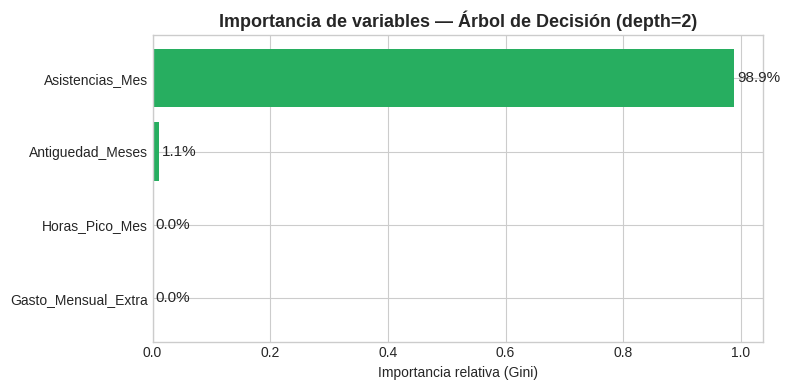

Ranking de importancia:
  Asistencias_Mes           98.9%
  Antiguedad_Meses          1.1%
  Horas_Pico_Mes            0.0%
  Gasto_Mensual_Extra       0.0%


In [12]:
imp = pd.DataFrame({
    "feature": X.columns,
    "importance": tree.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(imp["feature"], imp["importance"], color="#27ae60")
for bar, v in zip(bars, imp["importance"]):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.1%}",
            va="center", fontsize=11)
ax.set_title("Importancia de variables — Árbol de Decisión (depth=2)", fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia relativa (Gini)")
plt.tight_layout()
plt.show()

print("Ranking de importancia:")
for _, row in imp.sort_values("importance", ascending=False).iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.1%}")

**Hallazgo clave:** `Asistencias_Mes` concentra el **98,9%** de la importancia del modelo. `Antiguedad_Meses` aporta un 1,1% (la segunda pregunta del árbol). `Horas_Pico_Mes` y `Gasto_Mensual_Extra` no aparecen en el modelo — con solo 2 niveles de profundidad, el árbol no las necesita.

Esto no significa que sean inútiles — significa que `Asistencias_Mes` absorbe toda la señal que necesita un modelo de 2 reglas. Los notebooks de [Random Forest](../02-random-forest/) y [XGBoost](../03-xgboost/) muestran cómo se redistribuye la importancia cuando el modelo tiene más capacidad.

## 9. Insights de negocio y recomendaciones

### El hallazgo

> La satisfacción de un cliente depende casi exclusivamente de **con qué frecuencia usa el gimnasio**. El modelo más simple posible — dos preguntas — captura el 90% de la realidad.

### Recomendaciones

**1. Sistema de alerta temprana (impacto: alto, esfuerzo: bajo)**
Clientes con <10 asistencias/mes durante 2 meses consecutivos entran automáticamente en pipeline de retención. Sin modelo ML, sin infraestructura — un filtro en el CRM.

**2. Onboarding intensivo los primeros 3 meses (impacto: alto)**
El árbol muestra que la antigüedad importa solo en los primeros meses. El objetivo: llevar al cliente por encima de 13 asistencias/mes antes de que acabe su tercer mes.

**3. KPI operativo diario (impacto: medio, esfuerzo: bajo)**
`% clientes con ≥14 asistencias/mes` como proxy de satisfacción en tiempo real. Es más barato, más rápido y más objetivo que cualquier encuesta.

**4. Exportar la regla a producción (impacto: estratégico)**
Un árbol de 2 reglas puede implementarse como un `IF-ELSE` en cualquier sistema. No necesita Python, no necesita servidor ML, no necesita mantenimiento. Es el modelo más desplegable que existe.